In [1]:
# Tudat imports for propagation and estimation
from tudatpy.interface import spice
from tudatpy import dynamics
from tudatpy.dynamics import environment_setup
from tudatpy.dynamics import propagation_setup, parameters_setup, simulator
from tudatpy import estimation
from tudatpy.estimation import observable_models_setup, observable_models, observations_setup, observations, estimation_analysis
from tudatpy.astro.time_representation import DateTime
from tudatpy.util import result2array

# import MPC interface
from tudatpy.data.mpc import BatchMPC

# import SBDB interface
from tudatpy.data.sbdb import SBDBquery

# other useful modules
import numpy as np
import datetime

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.cm as cm

# Horizons
from tudatpy.data.horizons import HorizonsQuery

In [2]:
# SPICE KERNELS
spice.load_standard_kernels()

In [3]:
target_mpc_code = 66146

observations_start = datetime.datetime(2000,1,1)
observations_end = datetime.datetime(2020, 1, 1)

# number of iterations for our estimation
number_of_pod_iterations = 1

# timestep of 20 hours for our estimation
timestep_global = 20 * 3600.0

# 1 month time buffer used to avoid interpolation errors:
time_buffer = 1 * 31 * 86400.0

# define the frame origin and orientation.
global_frame_origin = "SSB"
global_frame_orientation = "J2000"

In [4]:
target_sbdb = SBDBquery(target_mpc_code)

mpc_codes = [target_mpc_code]  # the BatchMPC interface requires a list.
target_spkid = target_sbdb.codes_300_spkid  # the ID used by the
target_name = target_sbdb.name  # the ID used by the

print(f"SPK ID for {target_name} is: {target_spkid}")

SPK ID for 66146 (1998 TU3) is: 2066146


In [5]:
batch = BatchMPC()
batch.get_observations(mpc_codes)
batch.filter(
    epoch_start=observations_start,
    epoch_end=observations_end,
)

batch.summary()


   Batch Summary:
1. Batch includes 1 minor planets:
   ['66146']
2. Batch includes 1178 observations, including 70 observations from space telescopes
3. The observations range from 2000-09-03 08:49:24.959992 to 2019-12-29 09:08:55.680015
   In seconds TDB since J2000: 21243029.142585397 to 630882604.8638284
   In Julian Days: 2451790.86765 to 2458846.8812
4. The batch contains observations from 62 observatories, including 1 space telescopes



/home/joris/miniconda3/envs/tudat-space/lib/python3.10/site-packages/tudatpy/data/mpc/mpc.py:866: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['66146' '66146' '66146' ... '66146' '66146' '66146']' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  obs.loc[:, "number"] = obs.number.astype(str)


In [6]:
print(batch.table)

     number     desig discovery note1 note2         epoch        RA       DEC  \
181   66146  1998 TU3       NaN     1     C  2.451791e+06  3.446430 -0.127401   
182   66146  1998 TU3       NaN     1     C  2.451791e+06  3.446455 -0.127413   
183   66146  1998 TU3       NaN   NaN     C  2.451821e+06  4.311248 -0.445896   
184   66146  1998 TU3       NaN   NaN     C  2.451821e+06  4.311315 -0.445911   
185   66146  1998 TU3       NaN   NaN     C  2.451821e+06  4.327274 -0.449074   
...     ...       ...       ...   ...   ...           ...       ...       ...   
1354  66146  1998 TU3       NaN   NaN     C  2.458847e+06  5.984746 -0.224688   
1355  66146  1998 TU3       NaN   NaN     C  2.458847e+06  5.984773 -0.224668   
1356  66146  1998 TU3       NaN   NaN     C  2.458847e+06  5.984791 -0.224652   
1357  66146  1998 TU3       NaN   NaN     C  2.458847e+06  5.984815 -0.224635   
1358  66146  1998 TU3       NaN   NaN     C  2.458847e+06  5.984837 -0.224620   

       mag band catalog obs

In [7]:
print("Summary of space telescopes in batch:")
print(batch.observatories_table(only_space_telescopes=True))

Summary of space telescopes in batch:
     Code  Name  count
1239  C51  WISE   70.0


In [8]:
#obs_by_WISE = (
#    batch.table.query("observatory == 'C51'")
#    .loc[:, ["number", "epochJ2000secondsTDB", "RA", "DEC"]]
#    .iloc[[0, -1]]
#)

#print("\nInitial and Final Observations by WISE:")
#print(obs_by_WISE)

In [9]:
# List the bodies for our environment
bodies_to_create = [
    "Sun",
    "Mercury",
    "Venus",
    "Earth",
    "Moon",
    "Mars",
    "Jupiter",
    "Saturn",
    "Uranus",
    "Neptune",
]
epoch_start_nobuffer = batch.epoch_start
epoch_end_nobuffer = batch.epoch_end

epoch_start_buffer = epoch_start_nobuffer - time_buffer
epoch_end_buffer = epoch_end_nobuffer + time_buffer
# Create system of bodies
body_settings = environment_setup.get_default_body_settings(
    bodies_to_create, global_frame_origin, global_frame_orientation
)

query = HorizonsQuery(
    query_id="66146",
    location="@0",
    epoch_start=epoch_start_buffer,
    epoch_end=epoch_end_buffer,
    epoch_step="20h",
    extended_query=True,
)

body_settings.add_empty_settings("66146")

body_settings.get("66146").ephemeris_settings = (
    query.create_ephemeris_tabulated(
        frame_origin="SSB",
        frame_orientation="J2000",
    )
)


bodies = environment_setup.create_system_of_bodies(body_settings)

#bodies = environment_setup.create_system_of_bodies(body_settings)

# Retrieve Eros' body name from BatchMPC and set its centre to enable its propagation
bodies_to_propagate = batch.MPC_objects
central_bodies = [global_frame_origin]

In [10]:
# Transform the MPC observations into a tudat compatible format.
# note that we explicitly exclude all satellite observations in this step by setting included satellites to None.
observation_collection = batch.to_tudat(bodies=bodies, included_satellites=None)

# set create angular_position settings for each link in the list.
observation_settings_list = list()
link_list = list(
    observation_collection.get_link_definitions_for_observables(
        observable_type=observable_models_setup.model_settings.angular_position_type
    )
)

for link in link_list:
    # add optional bias settings here
    observation_settings_list.append(
        observable_models_setup.model_settings.angular_position(link, bias_settings=None)
    )
# Retrieve the first and final observation epochs and add the buffer


/home/joris/miniconda3/envs/tudat-space/lib/python3.10/site-packages/tudatpy/data/mpc/mpc.py:147: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  bias_dataframe = bias_dataframe.stack(level=0)


In [38]:


observation_simulators = observations_setup.observations_simulation_settings.create_observation_simulators(
    observation_settings_list,
    bodies
)
           
observations.compute_residuals_and_dependent_variables(
    observation_collection = observation_collection,
    observation_simulators = observation_simulators,
    bodies = bodies,
)

computed_res = observation_collection.get_residuals()

for i in computed_res:
    print("mean:", np.mean(i), "std:", np.std(i), "max:", np.max(np.abs(i)))

mean: 2.7855551442660462 std: 3.118601169873642 max: 6.3005716240439575
mean: -0.008933982317113445 std: 0.05748354378860681 max: 0.06642172316254163
mean: -0.022219524334852185 std: 0.033705986094800404 max: 0.05931782619528997
mean: 0.07285620255129564 std: 0.6069790624194908 max: 6.343115631810385
mean: -0.030737791347862527 std: 0.01611385364274401 max: 0.04940677288698782
mean: -0.013975706037538393 std: 0.014827338849958422 max: 0.030171519582099376
mean: -0.02011224306767563 std: 0.040152426215753614 max: 0.06587907116260744
mean: -0.03316472743460421 std: 0.010393156269280853 max: 0.04355917651931698
mean: 3.1065838451218206 std: 3.179967499246098 max: 6.31218759970836
mean: 0.027498565942400355 std: 0.08894268340026819 max: 0.30609810541923954
mean: 2.1000765681543667 std: 2.906548225755427 max: 5.058477850253308
mean: -0.013967217548883963 std: 0.014693315670296669 max: 0.028662871895968056
mean: 0.5161251897932027 std: 1.747416420591887 max: 6.3107071133249075
mean: 0.175832

In [12]:
# Define accelerations
accelerations = {
    "Sun": [
        propagation_setup.acceleration.point_mass_gravity(),
        propagation_setup.acceleration.relativistic_correction(use_schwarzschild=True),
    ],
    "Mercury": [propagation_setup.acceleration.point_mass_gravity()],
    "Venus": [propagation_setup.acceleration.point_mass_gravity()],
    "Earth": [propagation_setup.acceleration.point_mass_gravity()],
    "Moon": [propagation_setup.acceleration.point_mass_gravity()],
    "Mars": [propagation_setup.acceleration.point_mass_gravity()],
    "Jupiter": [propagation_setup.acceleration.point_mass_gravity()],
    "Saturn": [propagation_setup.acceleration.point_mass_gravity()],
    "Uranus": [propagation_setup.acceleration.point_mass_gravity()],
    "Neptune": [propagation_setup.acceleration.point_mass_gravity()],
}

# Set up the accelerations settings for each body, in this case only Eros
acceleration_settings = {}
for body in batch.MPC_objects:
    acceleration_settings[str(body)] = accelerations

# create the acceleration models.
acceleration_models = propagation_setup.create_acceleration_models(
    bodies, acceleration_settings, bodies_to_propagate, central_bodies
)

In [13]:
# benchmark state for later comparison retrieved from SPICE
initial_states = HorizonsQuery(
    query_id="66146;",
    location="@0",  # SSB
    epoch_start = epoch_start_buffer,
    epoch_end = epoch_end_buffer,
    epoch_step = "20h",
    extended_query=True,
)

# Add random offset for initial guess
rng = np.random.default_rng(seed=1)

initial_position_offset = 1e6 * 1000
initial_velocity_offset = 100

jpl_vector = initial_states.cartesian(frame_orientation="J2000")
initial_jpl_vector = jpl_vector[0][1:7]
initial_guess = initial_jpl_vector.copy()
initial_guess[0:3] += (2 * rng.random(3) - 1) * initial_position_offset
initial_guess[3:6] += (2 * rng.random(3) - 1) * initial_velocity_offset

print("Error between the real initial state and our initial guess:")
print(initial_guess - initial_jpl_vector)

Error between the real initial state and our initial guess:
[ 2.36432494e+07  9.00927393e+08 -7.11680775e+08  8.97298894e+01
 -3.76337096e+01 -1.53347102e+01]


In [14]:
print(initial_jpl_vector)

[-6.15402020e+10  4.05786846e+09  7.74075709e+09 -2.30140363e+03
 -5.23763593e+04 -2.12241359e+04]


In [15]:
# Create numerical integrator settings
integrator_settings = propagation_setup.integrator.runge_kutta_variable_step_size(
    timestep_global,
    propagation_setup.integrator.CoefficientSets.rkf_78,
    timestep_global,
    timestep_global,
    1.0,
    1.0,
)
# Terminate at the time of oldest observation
termination_condition = propagation_setup.propagator.time_termination(epoch_end_buffer)


# Create propagation settings
propagator_settings = propagation_setup.propagator.translational(
    central_bodies=central_bodies,
    acceleration_models=acceleration_models,
    bodies_to_integrate=bodies_to_propagate,
    initial_states=initial_guess,
    initial_time=epoch_start_buffer,
    integrator_settings=integrator_settings,
    termination_settings=termination_condition,
)

In [16]:
# Setup parameters settings to propagate the state transition matrix
parameter_settings = parameters_setup.initial_states(
    propagator_settings, bodies
)

# Create the parameters that will be estimated
parameters_to_estimate = parameters_setup.create_parameter_set(
    parameter_settings, bodies, propagator_settings
)

In [17]:
# Set up the estimator
estimator = estimation_analysis.Estimator(
    bodies=bodies,
    estimated_parameters=parameters_to_estimate,
    observation_settings=observation_settings_list,
    propagator_settings=propagator_settings,
    integrate_on_creation=True,
)

# provide the observation collection as input, and limit number of iterations for estimation.
pod_input = estimation_analysis.EstimationInput(
    observations_and_times=observation_collection,
    convergence_checker=estimation.estimation_analysis.estimation_convergence_checker(
        maximum_iterations=number_of_pod_iterations,
    ),
)

# Set methodological options
pod_input.define_estimation_settings(reintegrate_variational_equations=True)

In [18]:
# Perform the estimation
pod_output = estimator.perform_estimation(pod_input)

Calculating residuals and partials 2216
Current residual: 2.24722
Maximum number of iterations reached
Parameter update 3.07744e+10 -4.48243e+09 -1.20916e+10      3939.53       -27836      14676.6
Final residual: 2.24722


Warning, detected jump in observation residual of size 5.98527 for observable type 1
Warning, detected jump in observation residual of size 5.04798 for observable type 1
Warning, detected jump in observation residual of size 5.76911 for observable type 1
Warning, detected jump in observation residual of size 5.76903 for observable type 1
Warning, detected jump in observation residual of size 5.76918 for observable type 1
Warning, detected jump in observation residual of size 5.76909 for observable type 1
Warning, detected jump in observation residual of size 5.76925 for observable type 1
Warning, detected jump in observation residual of size 5.76909 for observable type 1
Warning, detected jump in observation residual of size 5.76938 for observable type 1
Warning, detected jump in observation residual of size 5.76929 for observable type 1
Warning, detected jump in observation residual of size 5.76946 for observable type 1
Warning, detected jump in observation residual of size 5.76938 fo

In [19]:
# retrieve the estimated initial state.
results_final = pod_output.parameter_history[:, -1]

vector_error_initial = (np.array(initial_guess) - initial_jpl_vector)[0:3]
error_magnitude_initial = np.sqrt(np.square(vector_error_initial).sum()) / 1000

vector_error_final = (np.array(results_final) - initial_jpl_vector)[0:3]
error_magnitude_final = np.sqrt(np.square(vector_error_final).sum()) / 1000

print(
    f"{target_name} initial guess radial error to spice: {round(error_magnitude_initial, 2)} km"
)
print(
    f"{target_name} final radial error to spice: {round(error_magnitude_final, 2)} km"
)

66146 (1998 TU3) initial guess radial error to spice: 1148354.78 km
66146 (1998 TU3) final radial error to spice: 33545056.32 km


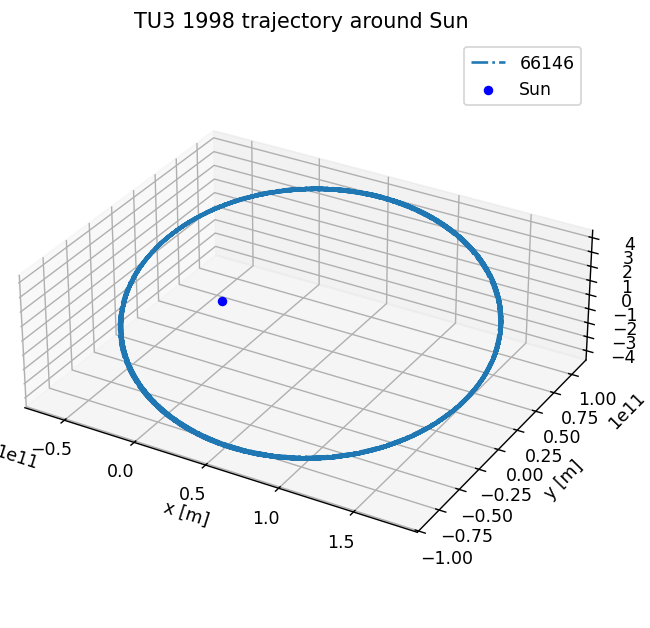

In [20]:
# Create simulation object and propagate the dynamics
dynamics_simulator = simulator.create_dynamics_simulator(
    bodies, propagator_settings
)
# Extract the resulting state history and convert it to an ndarray
states = dynamics_simulator.propagation_results.state_history
states_array = result2array(states)

# Define a 3D figure using pyplot
fig = plt.figure(figsize=(6,6), dpi=125)
ax = fig.add_subplot(111, projection='3d')
ax.set_title(f'TU3 1998 trajectory around Sun')

# Plot the positional state history
ax.plot(states_array[:, 1], states_array[:, 2], states_array[:, 3], label=bodies_to_propagate[0], linestyle='-.')
ax.scatter(0.0, 0.0, 0.0, label="Sun", marker='o', color='blue')

# Add the legend and labels, then show the plot
ax.legend()
ax.set_xlabel('x [m]')
ax.set_ylabel('y [m]')
ax.set_zlabel('z [m]')
ax.set_aspect('equal')
plt.show()

IndexError: index 1 is out of bounds for axis 1 with size 1

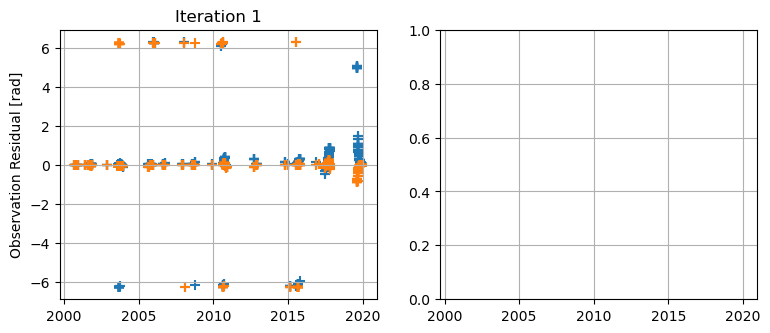

In [21]:
residual_history = pod_output.residual_history

# Number of columns and rows for our plot
number_of_columns = 2

number_of_rows = (
    int(number_of_pod_iterations / number_of_columns)
    if number_of_pod_iterations % number_of_columns == 0
    else int((number_of_pod_iterations + 1) / number_of_columns)
)

fig, axs = plt.subplots(
    number_of_rows,
    number_of_columns,
    figsize=(9, 3.5 * number_of_rows),
    sharex=True,
    sharey=False,
)

# We cheat a little to get an approximate year out of our times (which are in seconds since J2000)
residual_times = (
    np.array(observation_collection.concatenated_times) / (86400 * 365.25) + 2000
)


# plot the residuals, split between RA and DEC types
for idx, ax in enumerate(fig.get_axes()):
    ax.grid()
    # we take every second
    ax.scatter(
        residual_times[::2],
        residual_history[
            ::2,
            idx,
        ],
        marker="+",
        s=60,
        label="Right Ascension",
    )
    ax.scatter(
        residual_times[1::2],
        residual_history[
            1::2,
            idx,
        ],
        marker="+",
        s=60,
        label="Declination",
    )
    ax.set_ylabel("Observation Residual [rad]")
    ax.set_title("Iteration " + str(idx + 1))

plt.tight_layout()

# add the year label for the x-axis
for col in range(number_of_columns):
    axs[int(number_of_rows - 1), col].set_xlabel("Year")

axs[0, 0].legend()

plt.show()

In [ ]:
# Correlation can be retrieved using the CovarianceAnalysisInput class:
covariance_input = estimation_analysis.CovarianceAnalysisInput(observation_collection)
covariance_output = estimator.compute_covariance(covariance_input)

correlations = covariance_output.correlations
estimated_param_names = ["x", "y", "z", "vx", "vy", "vz"]


fig, ax = plt.subplots(1, 1, figsize=(9, 7))

im = ax.imshow(correlations, cmap=cm.RdYlBu_r, vmin=-1, vmax=1)

ax.set_xticks(np.arange(len(estimated_param_names)), labels=estimated_param_names)
ax.set_yticks(np.arange(len(estimated_param_names)), labels=estimated_param_names)

# add numbers to each of the boxes
for i in range(len(estimated_param_names)):
    for j in range(len(estimated_param_names)):
        text = ax.text(
            j, i, round(correlations[i, j], 2), ha="center", va="center", color="w"
        )

cb = plt.colorbar(im)

ax.set_xlabel("Estimated Parameter")
ax.set_ylabel("Estimated Parameter")

fig.suptitle(f"Correlations for estimated parameters for {target_name}")

fig.set_tight_layout(True)

In [ ]:
# lets get ranges for all gaps larger than 6 months:
gap_in_months = 6

gaps = np.abs(np.diff(sorted(residual_times)))
num_gaps = (
    gaps > (gap_in_months / 12)
).sum()  # counts the number of gaps larger than 0.5 years
indices_of_largest_gaps = np.argsort(gaps)[-num_gaps:]

# (start, end) for each of the gaps
gap_ranges = [
    (sorted(residual_times)[idx - 1], sorted(residual_times)[idx + 1])
    for idx in indices_of_largest_gaps
]

print(f"Largest gap = {round(max(gaps), 3)} years")
print(gap_ranges)

In [ ]:
# Now lets plot the orbit error
fig, ax = plt.subplots(1, 1, figsize=(9, 5))

# show areas where there are no observations:
for i, gap in enumerate(gap_ranges):
    ax.axvspan(
        xmin=gap[0],
        xmax=gap[1],
        color="red",
        alpha=0.1,
        label="Large gap in observations" if i == 0 else None,
    )

spice_states = []
estimation_states = []

# retrieve the states for a list of times.
times = np.linspace(epoch_start_nobuffer, epoch_end_nobuffer, 1000)
times_plot = times / (86400 * 365.25) + 2000  # approximate
for time in times:
    # from spice
    state_spice = spice.get_body_cartesian_state_at_epoch(
        target_spkid, central_bodies[0], global_frame_orientation, "NONE", time
    )
    spice_states.append(state_spice)

    # from estimation
    state_est = bodies.get(str(target_mpc_code)).ephemeris.cartesian_state(time)
    estimation_states.append(state_est)

# Error in kilometers
error = (np.array(spice_states) - np.array(estimation_states)) / 1000

# plot
ax.plot(times_plot, error[:, 0], label="x")
ax.plot(times_plot, error[:, 1], label="y")
ax.plot(times_plot, error[:, 2], label="z")

ax.grid()
ax.legend(ncol=1)

plt.tight_layout()

ax.set_ylabel("Cartesian Error [km]")
ax.set_xlabel("Year")

fig.suptitle(f"Error vs SPICE over time for {target_name}")
fig.set_tight_layout(True)

plt.show()

In [ ]:
# 10 observatories with most observations
num_observatories = 10

final_residuals = np.array(residual_history[:, -1])
# if you would like to check the iteration 1 residuals, use:
# final_residuals = np.array(residual_history[:, 0])

In [ ]:
# This piece of code collects the 10 largest observatories
observatory_names = (
    batch.observatories_table(exclude_space_telescopes=True)
    .sort_values("count", ascending=False)
    .iloc[0:num_observatories]
    .set_index("Code")
)
top_observatories = observatory_names.index.tolist()

# This piece of code creates a `concatenated_receiving_observatories` map
# to identify the observatories by their MPC code instead of an internally used id
residuals_observatories = observation_collection.concatenated_link_definition_ids
unique_observatories = set(residuals_observatories)

observatory_link_to_mpccode = {
    idx: observation_collection.link_definition_ids[idx][
        observable_models_setup.links.receiver
    ].reference_point
    for idx in unique_observatories
}

# the resulting map (MPC code for each item in the residuals_history):
concatenated_receiving_observatories = np.array(
    [observatory_link_to_mpccode[idx] for idx in residuals_observatories]
)

# mask for the observatories not in top 10:
mask_not_top = [
    (False if observatory in top_observatories else True)
    for observatory in concatenated_receiving_observatories
]

# get the number of observations by the other observatories
# (divide by two because the observations are concatenated RA,DEC in this list)
n_obs_not_top = int(sum(mask_not_top) / 2)

In [ ]:
fig, axs = plt.subplots(2, 1, figsize=(13, 9))

# Plot remaining observatories first
# RA
axs[0].scatter(
    residual_times[mask_not_top][::2],
    final_residuals[mask_not_top][::2],
    marker=".",
    s=30,
    label=f"{len(unique_observatories) - num_observatories} Other Observatories | {n_obs_not_top} obs",
    color="lightgrey",
)
# DEC
axs[1].scatter(
    residual_times[mask_not_top][1::2],
    final_residuals[mask_not_top][1::2],
    marker=".",
    s=30,
    label=f"{len(unique_observatories) - num_observatories} Other Observatories | {n_obs_not_top} obs",
    color="lightgrey",
)

# plots the highlighted top 10 observatories
for observatory in top_observatories:
    name = f"{observatory} | {observatory_names.loc[observatory].Name} | {int(observatory_names.loc[observatory]['count'])} obs"
    axs[0].scatter(
        residual_times[concatenated_receiving_observatories == observatory][::2],
        final_residuals[concatenated_receiving_observatories == observatory][::2],
        marker=".",
        s=30,
        label=name,
        zorder=100,
    )
    axs[1].scatter(
        residual_times[concatenated_receiving_observatories == observatory][1::2],
        final_residuals[concatenated_receiving_observatories == observatory][1::2],
        marker=".",
        s=30,
        label=name,
        zorder=100,
    )


axs[1].legend(ncols=3, loc="upper center", bbox_to_anchor=(0.47, -0.15))

for ax in fig.get_axes():
    ax.grid()
    ax.set_ylabel("Observation Residual [rad]")
    ax.set_xlabel("Year")
    # this step hides a few outliers (~3 observations)
    ax.set_ylim(-1.5e-5, 1.5e-5)

axs[0].set_title("Right Ascension")
axs[1].set_title("Declination")

fig.suptitle(f"Final Iteration residuals for {target_name}")
fig.set_tight_layout(True)

plt.show()

In [ ]:
num_observatories = 6

data_per_observatory_list_RA = []
data_per_observatory_list_DEC = []
names = []

fig, ax = plt.subplots(1, 1, figsize=(10, 1.2 * num_observatories))

# we retrieve the observatory names again
observatory_names_box = (
    batch.observatories_table(exclude_space_telescopes=True)
    .set_index("Code")
    .sort_values("count", ascending=False)
    .iloc[0:num_observatories]
)

top_observatories_box = observatory_names_box.index.tolist()

# retrieve the data for RA and DEC separately
for observatory in top_observatories_box[::-1]:
    name = f"{observatory} | {observatory_names_box.loc[observatory].Name} | {int(observatory_names_box.loc[observatory]['count'])} obs"
    names.append(name)
    data_per_observatory_list_RA.append(
        final_residuals[concatenated_receiving_observatories == observatory][::2]
    )

    data_per_observatory_list_DEC.append(
        final_residuals[concatenated_receiving_observatories == observatory][1::2]
    )

# positioning the boxes
pos = (np.arange(0, len(top_observatories_box)) + 1) * 10
widths = 2.8
offset = 1.6

# box colors
RA_color = "tab:blue"
DEC_color = "tab:orange"

# boxes for RA and DEC
RAplots = ax.boxplot(
    x=data_per_observatory_list_RA,
    vert=False,
    positions=pos + offset,
    widths=widths,
    patch_artist=False,
    capprops=dict(color=RA_color),
    whiskerprops=dict(color=RA_color),
    flierprops=dict(color=RA_color, markeredgecolor=RA_color),
    medianprops=dict(color=RA_color),
)
DECplots = ax.boxplot(
    x=data_per_observatory_list_DEC,
    vert=False,
    positions=pos - offset,
    widths=widths,
    patch_artist=False,
    capprops=dict(color=DEC_color),
    whiskerprops=dict(color=DEC_color),
    flierprops=dict(color=DEC_color, markeredgecolor=DEC_color),
    medianprops=dict(color=DEC_color),
)
# custom ticks
ax.set_yticks(ticks=pos, labels=names)

# custom legend
place_holder_lines = [
    Line2D([0], [0], color=RA_color, lw=4),
    Line2D([0], [0], color=DEC_color, lw=4),
]
ax.legend(place_holder_lines, ["Right Ascension", "Declination"])

ax.grid()
ax.set_xlabel("Observation Residual [rad]")

fig.suptitle(
    f"Residual boxplots of the {num_observatories} observatories with the most observations for {target_name}"
)

# reducing whitespace
ax.set_ylim(10 - 4, int(len(top_observatories_box) * 10) + 4)

fig.set_tight_layout(True)
plt.show()

In [ ]:
num_observatories = 6
nbins = 20
number_of_columns = 2
transparency = 0.6

In [ ]:
number_of_rows = (
    int(num_observatories / number_of_columns)
    if num_observatories % number_of_columns == 0
    else int((num_observatories + 1) / number_of_columns)
)

# we retrieve the observatory names again
observatory_names_hist = (
    batch.observatories_table(exclude_space_telescopes=True)
    .set_index("Code")
    .sort_values("count", ascending=False)
    .iloc[0:num_observatories]
)

top_observatories_hist = observatory_names_hist.index.tolist()


fig, axs = plt.subplots(
    number_of_rows,
    number_of_columns,
    figsize=(4.5 * number_of_columns, 3 * number_of_rows),
)

axs = axs.flatten()

for idx, observatory in enumerate(top_observatories_hist):
    name = f"{observatory} | {observatory_names_hist.loc[observatory].Name} | {int(observatory_names_hist.loc[observatory]['count'])} obs"

    axs[idx].hist(
        final_residuals[concatenated_receiving_observatories == observatory][0::2],
        bins=nbins,
        alpha=transparency + 0.05,
        label="Right Ascension",
    )
    axs[idx].hist(
        final_residuals[concatenated_receiving_observatories == observatory][1::2],
        bins=nbins,
        alpha=transparency,
        label="Declination",
    )

    axs[idx].grid()
    axs[idx].set_title(name)
    axs[idx].set_ylabel("Number of Observations")
    axs[idx].set_xlabel("Observation Residual [rad]")

axs[0].legend()

fig.suptitle(
    f"Final residual histograms of the {num_observatories} observatories with the most observations for {target_name}"
)
fig.set_tight_layout(True)
plt.show()